<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-12 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Attention Networks </21> </html>

The tutorial will cover the following:

* Preparing a simple dataset for time series forecasting
* How to use a network built via SimpleRNN for time series forecasting
* Adding a custom attention layer to the SimpleRNN network

_________![image.png](attachment:0ad58c9b-2c05-4e8f-b456-56365c0e007f.png)

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, SimpleRNN
from tensorflow.keras import Model
from tensorflow.keras.layers import Layer

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

print(tf.__version__)

2.20.0


### The Dataset

We will create a fibonacci sequence dataset for our purpose. In Fibonacci sequence, one number is constructed from the previous two numbers. The first 10 numbers of the sequence are shown below:

0, 1, 1, 2, 3, 5, 8, 13, 21, 34, …


When given the previous ‘t’ numbers, can you get a machine to accurately reconstruct the next number? This would mean discarding all the previous inputs except the last two and performing the correct operation on the last two numbers.

For this tutorial, you’ll construct the training examples from t time steps and use the value at t+1 as the target. For example, if t=3, then the training examples and the corresponding target values would look as follows:


![image.png](attachment:image.png)

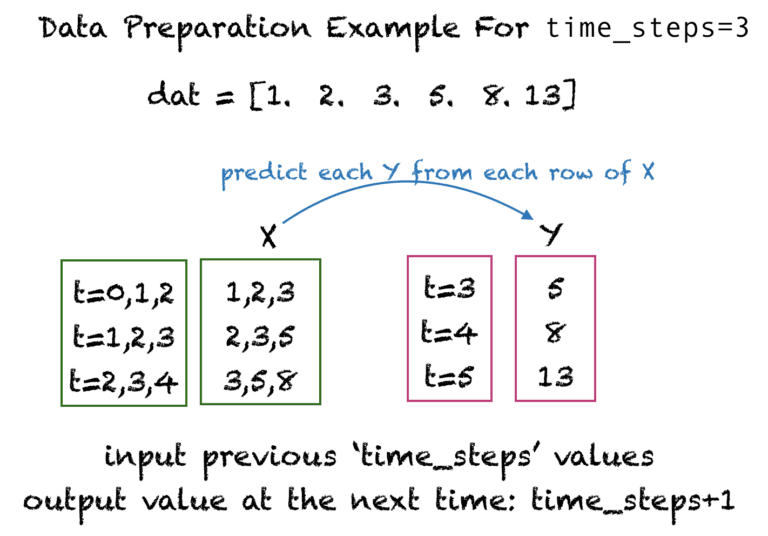

![image.png](attachment:image.png)

The Fibonacci spiral: an approximation of the **golden spiral** created by drawing circular arcs connecting the opposite corners of squares in the Fibonacci tiling

### Data preprocessing

_____________________![image.png](attachment:8d917c7c-28cf-41b6-8242-3dc62a9d37f5.png)

In [2]:
def get_fib_seq(n, scale_data=True):
    seq=np.zeros(n)
    fib_n1=0.0
    fib_n=1.0
    for i in range(n):
        seq[i] = fib_n1 +fib_n
        fib_n1 = fib_n
        fib_n =seq[i]

    scaler=[]
    if scale_data:
        scaler= MinMaxScaler(feature_range=(0,1))
        seq= np.reshape(seq,(n, 1))
        seq = scaler.fit_transform(seq).flatten()
    return seq, scaler

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.

In [ ]:
# Check if the function works correctly:
# Copy the previous cell, change the function name and add fib_n

________________________![image.png](attachment:18cddcac-477d-4e87-8b99-6dcacd5036d9.png)

In [3]:
def get_fib_seq_check(n, scale_data=True):
    seq=np.zeros(n)
    fib_n1=0.0
    fib_n=1.0
    for i in range(n):
        seq[i] = fib_n1 +fib_n
        fib_n1 = fib_n
        fib_n =seq[i]

    scaler=[]
    if scale_data:
        scaler= MinMaxScaler(feature_range=(0,1))
        seq= np.reshape(seq,(n, 1))
        seq = scaler.fit_transform(seq).flatten()
    return seq, scaler, fib_n

_________________![image.png](attachment:db321006-92cc-4c45-9708-928ab15601de.png)

In [4]:
n=4
dat, scaler, fib_N= get_fib_seq_check(n)
print('seq_normalised = ', dat, '\n'
      'seq  =', dat*(fib_N-1)+1)

seq_normalised =  [0.   0.25 0.5  1.  ] 
seq  = [1. 2. 3. 5.]


In [5]:
# Your code for the same checking with n=6

n=6
dat, scaler, fib_N= get_fib_seq_check(n)
print('seq_normalised = ', dat, '\n'
      'seq  =', dat*(fib_N-1)+1)


seq_normalised =  [0.         0.08333333 0.16666667 0.33333333 0.58333333 1.        ] 
seq  = [ 1.  2.  3.  5.  8. 13.]


In [6]:
# Your code for the same checking with n=8

n=8
dat, scaler, fib_N= get_fib_seq_check(n)
print('seq_normalised = ', dat, '\n'
      'seq  =', dat*(fib_N-1)+1)

seq_normalised =  [0.         0.03030303 0.06060606 0.12121212 0.21212121 0.36363636
 0.60606061 1.        ] 
seq  = [ 1.  2.  3.  5.  8. 13. 21. 34.]


In [7]:
# Your code for the same checking with n=10

n=10
dat, scaler, fib_N= get_fib_seq_check(n)
print('seq_normalised = ', dat, '\n'
      'seq  =', dat*(fib_N-1)+1)

seq_normalised =  [0.         0.01136364 0.02272727 0.04545455 0.07954545 0.13636364
 0.22727273 0.375      0.61363636 1.        ] 
seq  = [ 1.  2.  3.  5.  8. 13. 21. 34. 55. 89.]


___________________![image.png](attachment:7e618c91-f0e5-4de1-ba94-a64fa41371ef.png)

In [8]:
scaler

MinMaxScaler()

In [9]:
MinMaxScaler()

MinMaxScaler()

### The following function transforms the fibonacci sequence into training and test dataset.

X and Y looks like the following. From X and Y, we create training and test dataset.


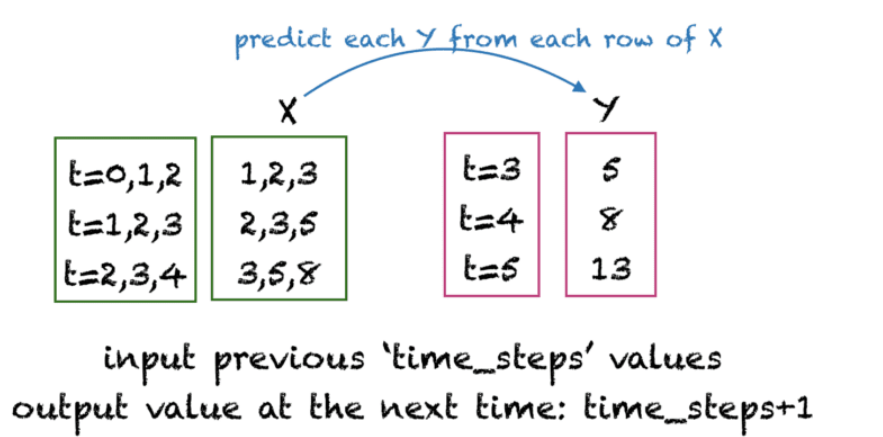

____________________![image.png](attachment:4c5f5581-f82f-4df3-9a8f-e565740db8f3.png)

In [10]:
def get_fib_XY(total_fib_numbers, time_steps, train_percent, scale_data=True):
    dat, scaler = get_fib_seq(total_fib_numbers, scale_data)

    Y_ind = np.arange(time_steps, len(dat), 1)
    Y = dat[Y_ind]
    rows_x=len(Y)
    X = dat[0:rows_x]
    for i in range(time_steps-1):
        temp = dat[i+1:rows_x+i+1]
        X=np.column_stack((X, temp))

    rand = np.random.RandomState(seed=13)
    idx = rand.permutation(rows_x)
    split= int(train_percent * rows_x)
    train_ind =idx[0:split]
    test_ind = idx[split:]
    trainX=X[train_ind]
    trainY=Y[train_ind]
    testX=X[test_ind]
    testY=Y[test_ind]
    trainX=np.reshape(trainX, (len(trainX), time_steps, 1))
    testX=np.reshape(testX, (len(testX), time_steps, 1))
    return trainX, trainY, testX, testY, scaler


_________________![image.png](attachment:f6c95298-4108-4f3d-a7bd-b411e900a952.png)

In [11]:
get_fib_XY(8, 3, 0.8)

(array([[[0.03030303],
         [0.06060606],
         [0.12121212]],
 
        [[0.12121212],
         [0.21212121],
         [0.36363636]],
 
        [[0.21212121],
         [0.36363636],
         [0.60606061]],
 
        [[0.        ],
         [0.03030303],
         [0.06060606]]]),
 array([0.21212121, 0.60606061, 1.        , 0.12121212]),
 array([[[0.06060606],
         [0.12121212],
         [0.21212121]]]),
 array([0.36363636]),
 MinMaxScaler())

In [ ]:
#np.column_stack?

In [ ]:
#np.random.RandomState.permutation?

### In the following code, we test the performance with the help of a simple RNN.


#### Set up parameters

__________________![image.png](attachment:2c3fc454-be8a-44bc-bddd-bf159366d371.png)

In [12]:
time_steps = 20
hidden_units =2
epochs = 40

#### Create a traditional RNN network

______________![image.png](attachment:b88e1fbb-1de4-4825-9870-7ee60b591bff.png)

In [13]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units,  input_shape=input_shape, activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mse', optimizer='adam')
    return model

___________________![image.png](attachment:3ca4d694-faeb-4cbf-9058-81ad2750ce9a.png)

In [14]:
model_RNN= create_RNN(hidden_units=hidden_units, dense_units=1, input_shape=(time_steps, 1),
                      activation=['tanh','tanh'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


![image.png](attachment:87ecc6c6-cdc0-4f5f-9fbf-9d5f1d482525.png)

##### tf.keras.activations.tanh

https://www.tensorflow.org/api_docs/python/tf/keras/activations/tanh

In [15]:
# Your code to print the model summary

#
model_RNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

________________________![image.png](attachment:6def3a3d-1d23-428e-bfdc-599c05882d55.png)

In [16]:
trainX, trainY, testX, testY, scaler = get_fib_XY(1200, time_steps, 0.7)

#### Train the network

_____________________![image.png](attachment:fdf0c280-b340-494d-a303-7662c76ee97c.png)

In [17]:
history = model_RNN.fit(trainX, trainY, epochs=epochs, batch_size=1, verbose=1)

Epoch 1/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0012    
Epoch 2/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0012
Epoch 3/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0011    
Epoch 4/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0010    
Epoch 5/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.9864e-04
Epoch 6/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.1705e-04
Epoch 7/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.0642e-04
Epoch 8/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.1699e-04
Epoch 9/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.2095e-04
Epoch 10/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.2728e-04
Epoch 11/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.4446e-04
Epoch 12/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.7531e-04
Epoch 13/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.1524e-04
Epoch 14/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7544e-04
Epoch

____________________![image.png](attachment:63ee9395-7301-4020-8459-f18c59469e89.png)

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.

___________________![image.png](attachment:0906917e-d0bd-4f2f-b06b-3ab1a64df7d0.png)

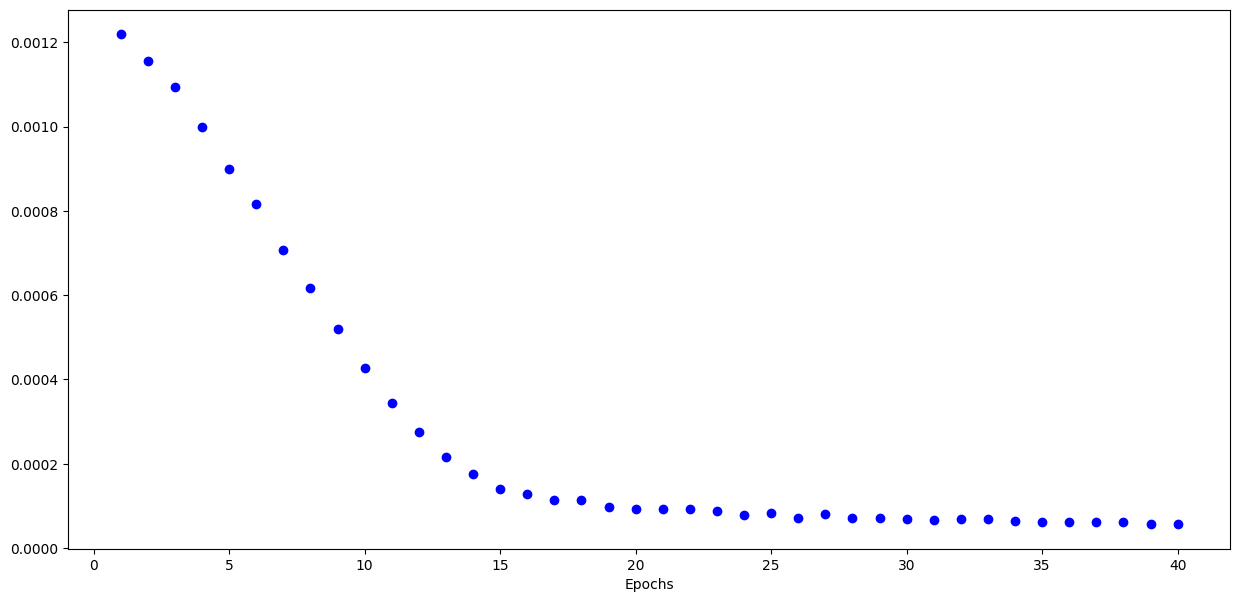

In [20]:
history_dict =history.history
losses = history_dict['loss']
epochs = range(1, len(losses) +1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'bo', label='Training loss')

plt.xlabel('Epochs')
plt.ylabel
plt.show()

#### Evalute model

____________________![image.png](attachment:704c6239-7252-4312-bf39-7787d8022c14.png)

In [21]:
train_mse = model_RNN.evaluate(trainX, trainY)
test_mse = model_RNN.evaluate(testX, testY)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.0678e-05
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.6597e-05


#### Print train and test error metrics

__________________![image.png](attachment:2ef16392-7c84-4b09-b6e0-3b3da59bfd22.png)

In [22]:
print("Train set MSE = ", train_mse)
print("Test set MSE = ", test_mse)

Train set MSE =  4.0678201912669465e-05
Test set MSE =  1.6596808563917875e-05


### The following code creates an attention layer. You need to understand each line to know how an attention layer can be created.


_____________________![image.png](attachment:71d7c411-79dc-4192-88e6-9173000987a8.png)

In [23]:
@tf.keras.utils.register_keras_serializable()
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
      self.W=self.add_weight(name="attention_weight", shape=(input_shape[-1],1),
                             initializer="random_normal", trainable=True)
      self.b=self.add_weight(name="attention_bias", shape=(1,),
                             initializer="zeros", trainable=True)
      super(Attention, self).build(input_shape)

    def call(self,x):
      e= tf.tanh(tf.matmul(x,self.W)+ self.b)
      e=tf.squeeze(e, axis=-1)
      alpha=tf.nn.softmax(e)

      alpha=tf.expand_dims(alpha, axis=-1)
      context=x*alpha
      context=tf.reduce_sum(context, axis=1)
      return context

    def compute_output_shape(self, input_shape):
      return input_shape[0], input_shape[-1]


### The following code develops an RNN with an attention layer to predict the Fibonacci sequence.



________________________![image.png](attachment:6e69b52b-48d7-4659-be59-e8002755800c.png)

In [24]:
def create_RNN_with_attention(hidden_units, dense_units, input_shape, activation):
    x=Input(shape=input_shape)

    RNN_layer=SimpleRNN(hidden_units,  return_sequences=True, activation=activation)(x)
    attention_layer=Attention()(RNN_layer)

    outputs=Dense(dense_units, trainable=True, activation=activation)(attention_layer)
    model=Model(inputs=x, outputs=outputs)
    model.compile(loss='mse', optimizer='adam')
    return model


________________![image.png](attachment:bcd5cc9e-72bb-461e-bd3d-d31961d0c619.png)

In [25]:
model_attention = create_RNN_with_attention(hidden_units=hidden_units, dense_units=1,
                                           input_shape=(time_steps, 1), activation='tanh')

In [26]:
# Your code to print the model summary

#
model_attention.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 20, 2)          │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 2)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Your code to fit the model
# save the results of the training to 'history_2' variable list
# use batch_size=1

history_2 = model_attention.fit(trainX, trainY, epochs = 40, batch_size=1, verbose=1)


Epoch 1/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0015
Epoch 2/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0015    
Epoch 3/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014
Epoch 4/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014    
Epoch 5/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014    
Epoch 6/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014
Epoch 7/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014
Epoch 8/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014
Epoch 9/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014
Epoch 10/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014
Epoch 11/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0014    
Epoch 12/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013
Epoch 13/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013
Epoch 14/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0013    
Epoch 15/40
826/826 ━━━━━━━━━━━━━━━━━

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.


_______________________![image.png](attachment:1b1f1396-b1ab-4e3f-9305-97926a7f8442.png)

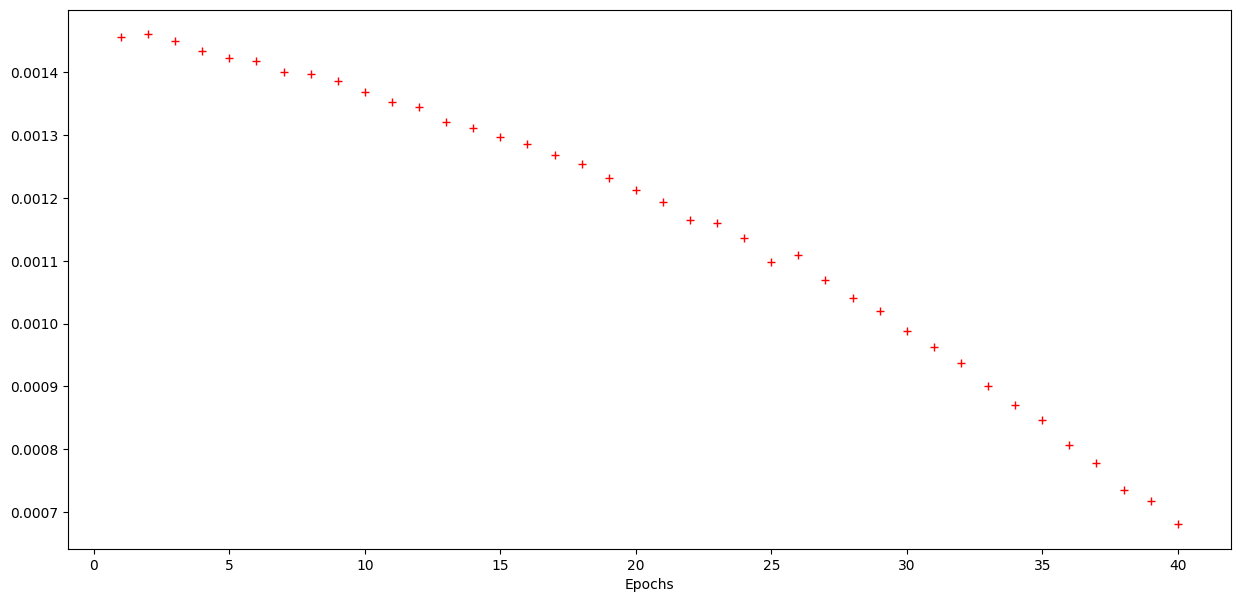

In [29]:
history_dict =history_2.history
losses = history_dict['loss']
epochs = range(1, len(losses) +1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'r+', label='Training loss')

plt.xlabel('Epochs')
plt.ylabel
plt.show()

In [30]:
# Your code to Evaluate attention model on training set
# Your code to evaluate the attention model on the test set

train_mse_attn =model_attention.evaluate(trainX, trainY)
test_mse_attn =model_attention.evaluate(testX, testY)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.3375e-04
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 5.3355e-04


In [33]:
# Your code to print train error metric
# Your code to print test error metric

print("Train set MSE with attention= ", train_mse_attn)
print("Test set MSE with attention= ", test_mse_attn)

Train set MSE with attention=  0.0006337536033242941
Test set MSE with attention=  0.0005335513851605356


In [ ]:
# Draw both loss functions' graphs together

________________________![image.png](attachment:74fcb146-ece0-40d3-8da7-5fe505256c97.png)

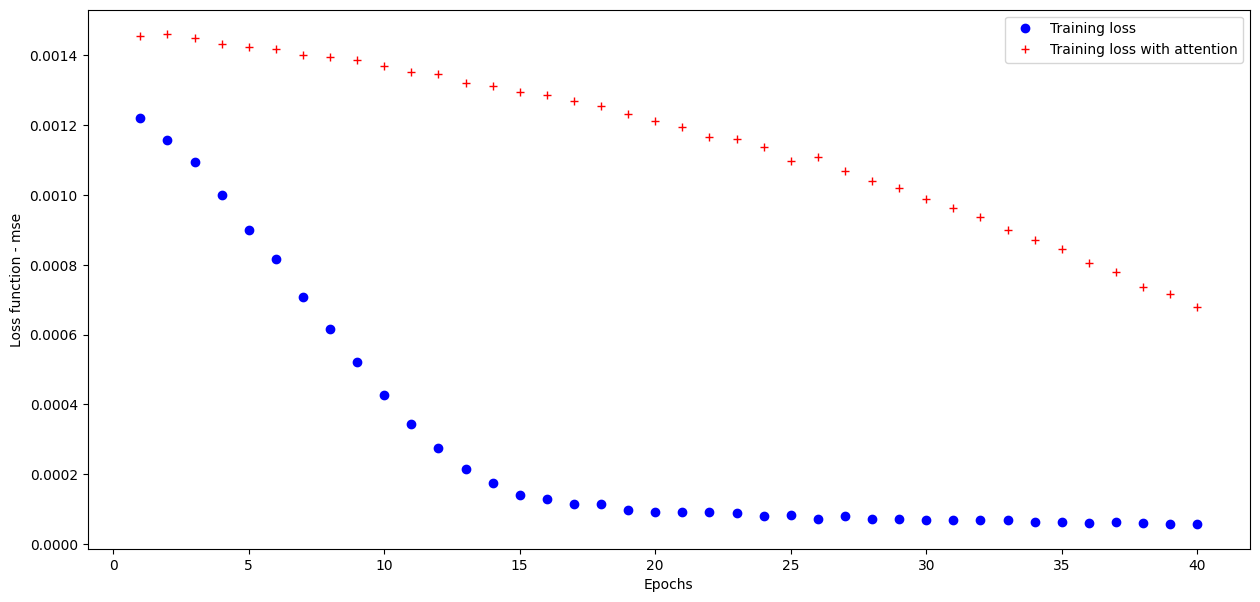

In [34]:
history_dict_1=history.history
history_dict_2=history_2.history

losses_1=history_dict_1['loss']
losses_2=history_dict_2['loss']

Epochs_1=range(1, len(losses_1)+1)
Epochs_2=range(1, len(losses_2)+1)
plt.figure(num=1, figsize=(15,7))

plt.plot(Epochs_1, losses_1, 'bo', label='Training loss')
plt.plot(Epochs_2, losses_2, 'r+', label='Training loss with attention')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

### Plot the train and test MSE performance for the 'Simple RNN' and 'RNN with an attention layer'.


_________________![image.png](attachment:83d9133a-4654-451e-9f28-f0b7c028c16e.png)

In [35]:
import pandas as pd

_______________________![image.png](attachment:b72b208e-2e1b-41a3-9588-ac2a8cc4c0b5.png)

In [36]:
ErrorMetrics =  [ [4.0678201912669465e-05, 1.6596808563917875e-05],
 [0.0006337536033242941, 0.0005335513851605356]
                  ]
ErrorMetrics

[[4.0678201912669465e-05, 1.6596808563917875e-05],
 [0.0006337536033242941, 0.0005335513851605356]]

____________![image.png](attachment:ccfec9cf-53db-49be-a7df-d1f1bd9283bc.png)

In [37]:
from copy import Error
ErrorMetrics_pd= pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd.columns= ['Train', 'Test']
ErrorMetrics_pd.index=['Simple RNN', 'RNN with attention']
ErrorMetrics_pd

,Train,Test
Simple RNN,0.000041,0.000017
RNN with attention,0.000634,0.000534


In [ ]:
## MSE performance histogram

__________________![image.png](attachment:829c3328-45a7-483c-bf5a-2def8578093f.png)

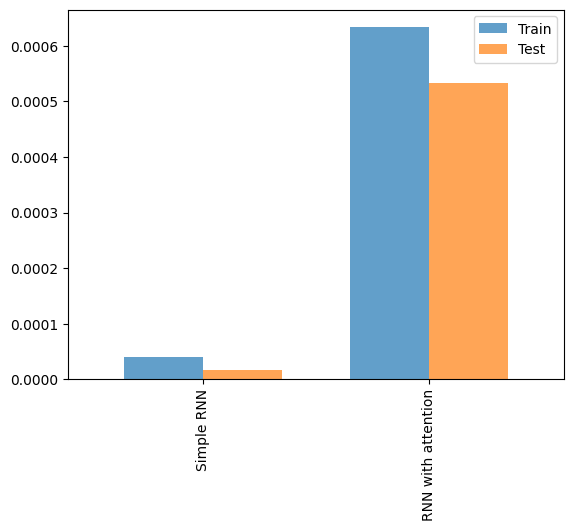

In [38]:
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)
plt.show()

# Lab Logbook Requirement:

<html> <h3 style="; color:blue;">

1) Modify the training parameter of the RNN with an attention layer model using the following formulas:

Modify the number of epochs:
Z + 50
, where your SID is: XXXXXXZ

Use EarlyStopping() and ModelCheckpoint() function to save the best modetl in the file 'best_attention_model.keras'
Modify the patience parameter:
Z + 10
, where your SID is: XXXXXXZ

2) Modify time_steps = 20 and hidden_units = 4
3) Leave other parameters the same as in the practical session
4) Calculate and demonstrate the received loss for train and test datasets
5) Plot the Loss function (MSE) graph during the training process for the 3 models together
6) Please only add to your Lab Logbook print-screens of:
- calculation of your parameters
- your code of using EarlyStopping() and ModelCheckpoint() functions
- your code and training result using model.fit()
- received loss for train and test datasets
- Loss (MSE) graph for the 3 models together during the training process
- performance histogram for train and test loss (MSE) of the 3 models together


</h3> </html>


<html> <h3 style="color:red;">
NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.
</h3> </html>

### Test the above model with different parameters, layer size, train and test ratio, and time steps.



__________________![image.png](attachment:f0dddc48-9aa3-4770-aaaf-eba0a9b046a7.png)

### Solution for Logbook

In [ ]:
# Your code of parameter modification
# time_steps = 20
# hidden_units = 4
# epochs = 56
# patience = 16

In [39]:
model_attention_modify = create_RNN_with_attention(hidden_units=4, dense_units=1,
                                           input_shape=(20, 1), activation='tanh')

In [40]:
model_attention_modify.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 20, 4)          │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_1 (Attention)         │ (None, 4)              │             5 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34 (136.00 B)

 Trainable params: 34 (136.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=16,
        mode='min',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_attention_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode='min',
        verbose=1
    )]

In [43]:
history_3 = model_attention_modify.fit(trainX, trainY, epochs = 56, batch_size=1,
                                 callbacks=[callbacks],
                                verbose=1)

Epoch 1/56
811/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0045e-04
Epoch 1: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0014    
Epoch 2/56
 35/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.8935e-09

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


821/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011
Epoch 2: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0014
Epoch 3/56
826/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3930e-04
Epoch 3: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0013    
Epoch 4/56
817/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 4: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0013
Epoch 5/56
812/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 5: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013
Epoch 6/56
816/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037
Epoch 6: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0012
Epoch 7/56
825/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063
Epoch 7: finishe

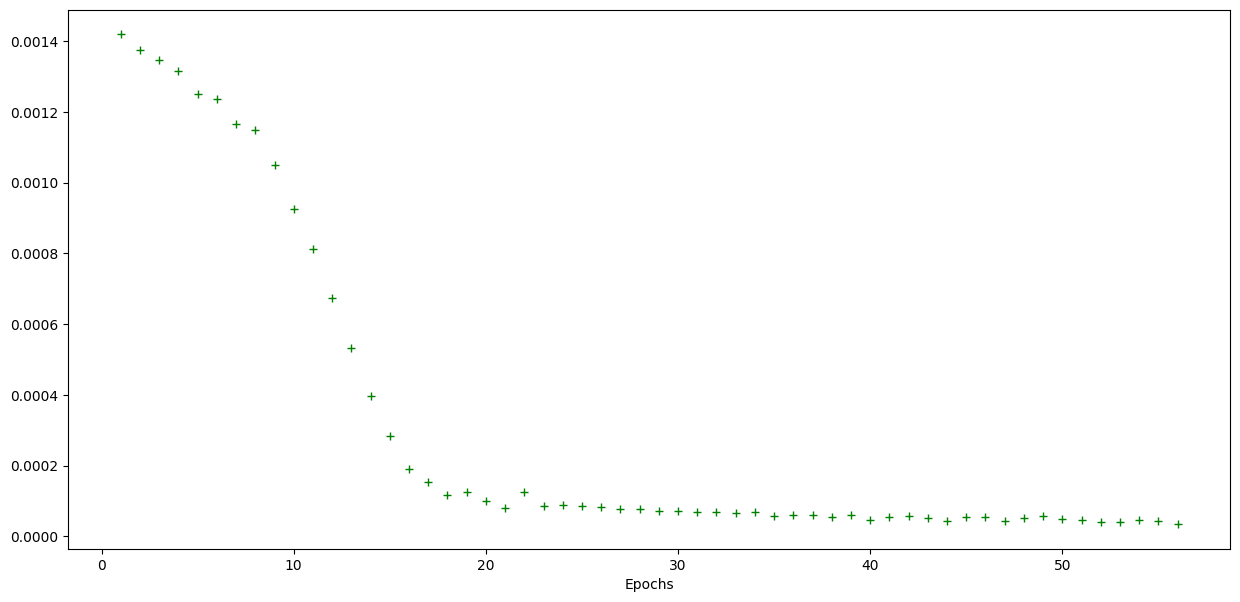

In [45]:
history_dict =history_3.history
losses = history_dict['loss']
epochs = range(1, len(losses) +1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'g+', label='Training loss')

plt.xlabel('Epochs')
plt.ylabel
plt.show()

In [46]:
train_mse_attn_1 =model_attention_modify.evaluate(trainX, trainY)
test_mse_attn_1 =model_attention_modify.evaluate(testX, testY)

print("Train set MSE with attention modified= ", train_mse_attn_1)
print("Test set MSE with attention modified= ", test_mse_attn_1)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 2.6481e-05
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.5782e-05
Train set MSE with attention modified=  2.648076588229742e-05
Test set MSE with attention modified=  2.5782292141229846e-05


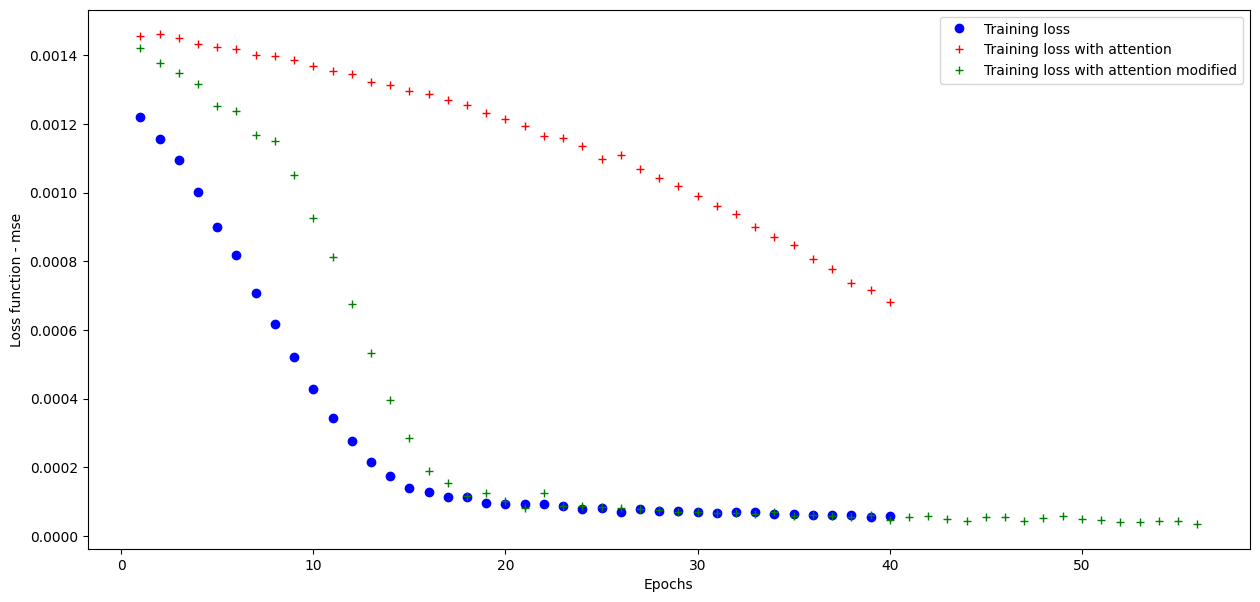

In [47]:
history_dict_1=history.history
history_dict_2=history_2.history
history_dict_3=history_3.history

losses_1=history_dict_1['loss']
losses_2=history_dict_2['loss']
losses_3=history_dict_3['loss']

Epochs_1=range(1, len(losses_1)+1)
Epochs_2=range(1, len(losses_2)+1)
Epochs_3=range(1, len(losses_3)+1)

plt.figure(num=1, figsize=(15,7))

plt.plot(Epochs_1, losses_1, 'bo', label='Training loss')
plt.plot(Epochs_2, losses_2, 'r+', label='Training loss with attention')
plt.plot(Epochs_3, losses_3, 'g+', label='Training loss with attention modified')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

________________![image.png](attachment:8e7ae2aa-24b8-420a-930f-d1da020dec6a.png)

In [48]:
ErrorMetrics =  [ [4.0678201912669465e-05, 1.6596808563917875e-05],
                  [0.0006337536033242941, 0.0005335513851605356],
                  [2.648076588229742e-05, 2.5782292141229846e-05]
                  ]
ErrorMetrics

[[4.0678201912669465e-05, 1.6596808563917875e-05],
 [0.0006337536033242941, 0.0005335513851605356],
 [2.648076588229742e-05, 2.5782292141229846e-05]]

In [49]:
from copy import Error
ErrorMetrics_pd= pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd.columns= ['Train', 'Test']
ErrorMetrics_pd.index=['Simple RNN', 'RNN with attention','RNN with attention modified']
ErrorMetrics_pd

,Train,Test
Simple RNN,0.000041,0.000017
RNN with attention,0.000634,0.000534
RNN with attention modified,0.000026,0.000026


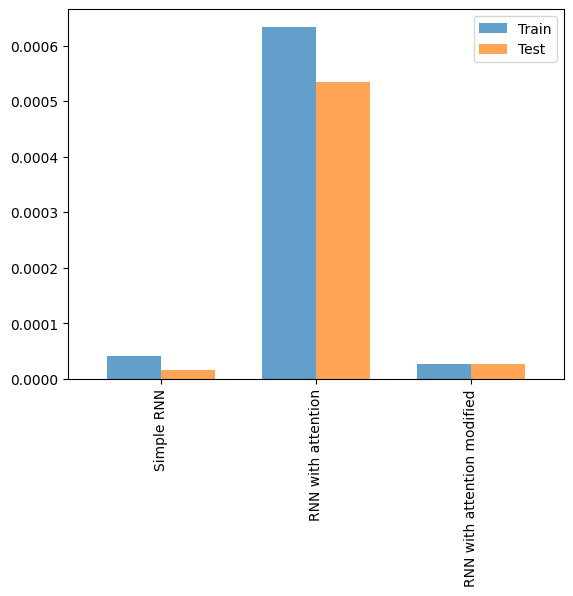

In [50]:
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)
plt.show()

In [55]:
import tensorflow as tf

Best_attention_model = tf.keras.models.load_model(
    'best_attention_model.keras',
    custom_objects={'attention': Attention}
)